# APE06U2: Distribuciones Continuas Notables-Grupo A

# Tarea 1

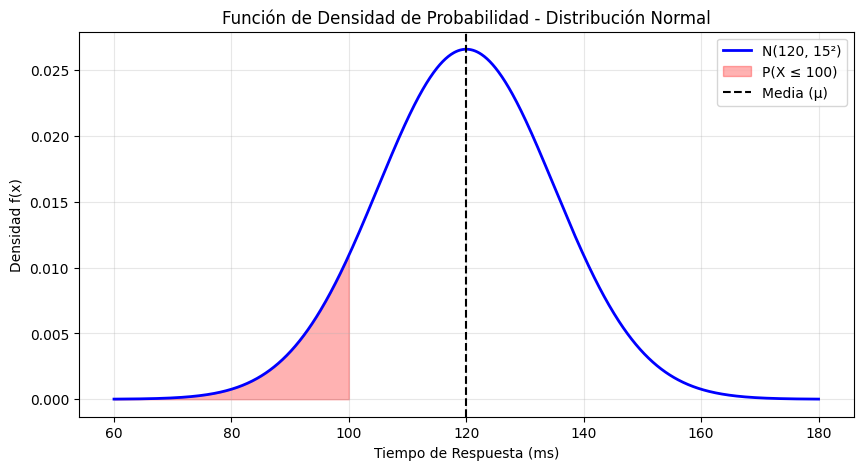

La probabilidad de que el servidor responda en 100ms o menos es: 0.0912 (9.12%)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Parámetros poblacionales
mu = 120
sigma = 15

# Definición del dominio (eje X): usualmente de mu-4sigma a mu+4sigma
x = np.linspace(mu - 4*sigma, mu + 4*sigma, 1000)

# Cálculo de la PDF teórica
pdf_normal = norm.pdf(x, loc=mu, scale=sigma)

# Configuración del gráfico
plt.figure(figsize=(10, 5))
plt.plot(x, pdf_normal, 'b-', lw=2, label=f'N({mu}, {sigma}²)')

# Sombreado del área de interés: P(X <= 100)
x_fill = np.linspace(mu - 4*sigma, 100)
y_fill = norm.pdf(x_fill, loc=mu, scale=sigma)
plt.fill_between(x_fill, y_fill, color='red', alpha=0.3, label='P(X ≤ 100)')

plt.title('Función de Densidad de Probabilidad - Distribución Normal')
plt.xlabel('Tiempo de Respuesta (ms)')
plt.ylabel('Densidad f(x)')
plt.axvline(mu, color='k', linestyle='--', label='Media (μ)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Cálculo analítico de la probabilidad usando CDF
prob_100 = norm.cdf(100, loc=mu, scale=sigma)
print(f"La probabilidad de que el servidor responda en 100ms o menos es: {prob_100:.4f} ({prob_100*100:.2f}%)")

# Tarea 2

In [ ]:
# Valor dado
X = 145

# Cálculo manual del valor Z
Z = (X - mu) / sigma

print(f"El valor Z para X = {X} ms es: {Z:.4f}")

# Probabilidad P(X ≥ 145)
prob_mayor_145 = 1 - norm.cdf(Z, loc=0, scale=1)

print(f"La probabilidad de que X sea mayor o igual a 145 ms es: {prob_mayor_145:.4f} ({prob_mayor_145*100:.2f}%)")

El valor Z para X = 145 ms es: 1.6667
La probabilidad de que X sea mayor o igual a 145 ms es: 0.0478 (4.78%)


# Tarea 3

In [ ]:
import pandas as pd
import scipy.stats as stats

# Definición de nombres (necesaria para el mapeo correcto)
nombres_columnas = [
    "Fecha", "Tipo", "Emisor", "Cantidad", "Valor_Nominal",
    "Precio", "Valor_Nominal_Total", "Monto_Efectivo",
    "Casa_Origen", "Casa_Destino", "Bolsa"
]

# Importar
df_bursatil = pd.read_csv("BVG_Acciones_export.csv",
                          names=nombres_columnas,
                          skiprows=1)

df_bursatil['Precio'] = pd.to_numeric(df_bursatil['Precio'], errors='coerce')
variable = df_bursatil['Precio'].dropna()

# Extracción de estadísticos (Media y Desviación Estándar)
mu = variable.mean()
sigma = variable.std()

# Escenario problemático
limite_inferior = 0.50  # a
limite_superior = 1.50  # b

# Cálculo de probabilidad
prob_critica = stats.norm.cdf(limite_superior, loc=mu, scale=sigma) - \
               stats.norm.cdf(limite_inferior, loc=mu, scale=sigma)

# Impresión de resultados
print(f"--- Análisis de Probabilidad Corregido ---")
print(f"Registros procesados: {len(variable)}")
print(f"Parámetros: μ = {mu:.4f}, σ = {sigma:.4f}")
print(f"Escenario: Probabilidad de precio en rango [{limite_inferior} - {limite_superior}] USD")
print(f"Resultado: {prob_critica:.4%}")

--- Análisis de Probabilidad Corregido ---
Registros procesados: 29131
Parámetros: μ = 42.6439, σ = 240.8388
Escenario: Probabilidad de precio en rango [0.5 - 1.5] USD
Resultado: 0.1632%


#### El resultado muestra que hay una baja probabilidad de que los precios caigan bajo ese rango definido, acompañado de la variación y media, podemos darnos cuenta de que es muy alta, por lo que los valores están muy dispersos entre sí. Por otra parte, podemos saber con más claridad la probabilidad de que el precio de una acción esté fuera del rango esperado.

# Tarea 4

Análisis basado en una muestra aleatoria de 5000 registros. Shapiro se vuelve impreciso ante más datos



<Figure size 800x600 with 0 Axes>

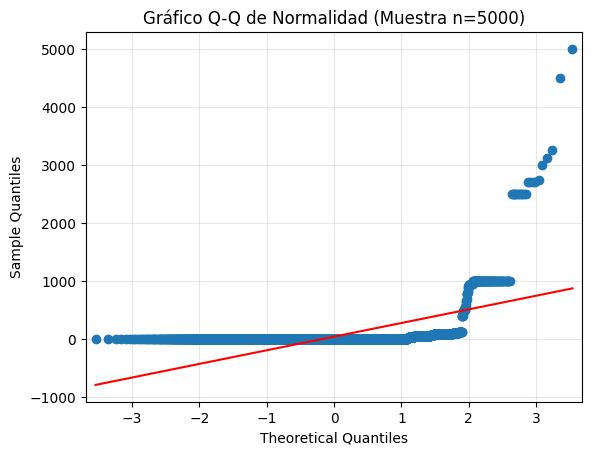

--- Resultados de la Prueba en la Muestra ---
Estadístico de Shapiro: 0.1646
p-valor: 1.2189e-91

CONCLUSIÓN: Con n=5000, se RECHAZA la normalidad. 


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy.stats import shapiro

# Preparación y limpieza de datos
nombres_columnas = ["Fecha", "Tipo", "Emisor", "Cantidad", "Valor_Nominal",
                    "Precio", "Valor_Nominal_Total", "Monto_Efectivo",
                    "Casa_Origen", "Casa_Destino", "Bolsa"]

df_regional = pd.read_csv("BVG_Acciones_export.csv", names=nombres_columnas, skiprows=1)
df_regional['Precio'] = pd.to_numeric(df_regional['Precio'], errors='coerce')
datos_completos = df_regional['Precio'].dropna()

# EXTRACCIÓN DE LA MUESTRA (Ajuste para N <= 5000) POR QUE SHAPIRO SE VUELVE IMPRECISO ANTE MÁS DATOS
n_muestra = 5000
datos_variable = datos_completos.sample(n=n_muestra, random_state=42)

print(f"Análisis basado en una muestra aleatoria de {n_muestra} registros. Shapiro se vuelve impreciso ante más datos\n")

# ---  MÉTODO GRÁFICO: Gráfico Q-Q ---
plt.figure(figsize=(8, 6))
sm.qqplot(datos_variable, line='s')
plt.title(f'Gráfico Q-Q de Normalidad (Muestra n={n_muestra})')
plt.grid(alpha=0.3)
plt.show()

# ---  MÉTODO ANALÍTICO: Test de Shapiro-Wilk ---
stat, p_value = shapiro(datos_variable)

print(f"--- Resultados de la Prueba en la Muestra ---")
print(f"Estadístico de Shapiro: {stat:.4f}")
print(f"p-valor: {p_value:.4e}")

# Conclusión estadística
alpha = 0.05
if p_value > alpha:
    print("\nCONCLUSIÓN: Con n=5000, los datos de la muestra parecen ser normales. ")
else:
    print("\nCONCLUSIÓN: Con n=5000, se RECHAZA la normalidad. ")

#### Los valores obtenidos no presentan una distribución normal, pues están muy dispersos dentro del dataset, debido a que hay valores de las transacciones efectuadas muy altos que rompen la simetría

# Preguntas de Control

# **1. Matemáticamente, ¿por qué en una variable aleatoria continua modelada por una función de densidad f(x), la probabilidad de que tome un valor exacto es cero, es decir, P(x)=c=0?**

#### Porque el valor requerido es infinito cuando se trata de variables contínuas y no puede dar un dato fijo matemáticamente, por eso se tiene que usar puntos o intervalos dentro de ese amplio rango de posibles resultados.

# **2. Intérprete conceptualmente qué significa que un valor de su dataset regional tenga un puntaje estándar de Z = -2.45 . ¿Se consideraría un valor atípico bajo el criterio de la regla empírica? ¿Es un valor atípico (outlier) según la Regla Empírica?**

#### Sí, bajo el criterio general de la regla empírica se considera un valor inusual o atípico, ya que supera las 2 desviaciones estándar por debajo de la media (|-2.45| > 2), ubicándose en una zona donde se encuentra un porcentaje muy pequeño y extremo de la población

#### La Regla Empírica se aplica a distribuciones con forma de campana (normales) y establece lo siguiente:
#### 68% de los datos están a +/- 1 desviación estándar de la media.
#### 95% de los datos están a +/- 2 desviaciones estándar de la media.
#### 99.7% de los datos están a +/- 3 desviaciones estándar de la media.

#### Bajo el criterio estándar de la regla empírica, un valor se suele considerar atípico si está más allá de +/- 2 o +/- 3 desviaciones estándar (dependiendo de qué tan estricto sea el análisis).
#### Como  |-2.45| > 2, el valor está fuera del 95% central de los datos. Sin embargo, todavía está dentro del rango de las 3 desviaciones estándar (que cubre el 99.7%).
#### Si usamos el criterio común de Z > |2|, entonces sí se considera un valor atípico. Es un valor inusual que sólo superaría (hacia la izquierda) a menos del 1% de la población total si la distribución es normal.

# **3. En la Tarea 3, calculó probabilidades asumiendo que su variable regional seguía una distribución Normal. ¿Qué riesgo metodológico existe al tomar decisiones basadas en este cálculo si la gráfica de la variable presenta un fuerte sesgo (skewness)?**
#### El hecho de que una variable presente un fuerte sesgo, permite que las acciones tomadas en base a ese modelo sean erradas, al momento de analizar los datos, se obtendrá un conocimiento erróneo y se procederá a tomar acciones con expectativas que nunca se cumpliran o se construiran modelos que fallarán al representar la realidad.

# **4. Con base en la Tarea 4 (ABI), si el p-valor del test de Shapiro-Wilk es 0.001, ¿cuál es la conclusión estadística respecto a la distribución de sus datos regionales? ¿Se invalida el cálculo realizado en la Tarea 3?**
#### La conclusión sería que los datos no siguen una distribución normal y por lo tanto los datos son dispares. Y por lo tanto, se invalida el cálculo realizado en la tarea 3, pues da un modelo que muestra aproximaciones erróneas y es óptimo para poder tomar decisiones fundamentadas.

# **5. Explique el principio matemático detrás del Gráfico Q-Q. ¿Qué representan los cuantiles teóricos en el eje X versus los cuantiles empíricos en el eje Y?**
#### El Gráfico Q-Q (Quantile-Quantile Plot) es una herramienta gráfica diseñada para comparar dos distribuciones de probabilidad comparando sus cuantiles. Su principio matemático se basa en la idea de que, si dos variables aleatorias siguen la misma distribución, la relación entre sus cuantiles será lineal
#### El eje horizontal (X) representa los cuantiles de una distribución teórica ideal
#### Matemáticamente: Se obtienen mediante la función cuantil inversa (F^-1) de la distribución que estamos probando.
#### Si tenemos n puntos de datos, dividimos la probabilidad acumulada total (1) en n+1 intervalos. Los cuantiles teóricos son los valores x tales que:
#### Xi  = F^-1 (i - 0.5/n)
#### El eje vertical (Y) representa los cuantiles de tus datos observados (la muestra real).
#### Matemáticamente: Para obtener estos valores, simplemente tomamos la muestra y la ordenamos de menor a mayor.
#### El primer dato ordenado es el cuantil empírico más bajo, el último es el más alto.


